# 09 — Machine Learning Foundations: Fitting Is Not Learning

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

> **Central question.** *What does it mean for a machine to learn from data, and why is fitting the training data not the same as learning?*

Part III uses the machinery of Part II with a twist that control does not have: **the cost that is minimized is not the cost that matters.** We minimize an average over the data we have; we care about data we have not seen. This notebook builds the vocabulary of machine learning — data, models, training — makes that distinction precise, shows it on a computable example, and fixes the protocol by which a trained model is judged.

### Table of Contents

1. **What machine learning is: a short map** — three ingredients, four paradigms
2. **The supervised learning problem** — empirical risk vs. population risk
3. **Data and representations** — how a word, a graph or a function becomes a vector
4. **Models** — linear regression, neural networks, classification outputs
5. **Training** — gradient descent, automatic differentiation and backpropagation
6. **Laboratory: polynomial regression** — train / validation / test in action
7. **Overfitting and the generalization gap**
8. **Selection bias** — why the training error is optimistic
9. **Training, validation and test sets** — the protocol
10. **A classifier on held-out data** — a two-class point cloud and the two moons
11. **Why the loss is not convex**
12. **Control ↔ ML**
13. **Federated learning** *(optional)*
14. **A zoo of architectures** — what each one assumes about the data
15. **Exercises**

### The mathematics behind machine learning

Machine learning is less a subject of its own than a meeting point. Analysis supplies approximation and the chain rule, linear algebra supplies the operations hardware can execute, probability supplies the very notion of generalization, optimization supplies the training algorithm, and dynamical systems and control supply the language for anything that evolves in time.

![A map of the mathematical fields underlying machine learning](images/math_of_ml.png)

In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import plotting as P           # the course palette, the house style, and the figure helpers

rng = np.random.default_rng(0)
torch.manual_seed(0);

## Where are we?

> **Recap.** A continuous, coercive functional on $\mathbb R^D$ has a minimizer; if its gradient is also Lipschitz, gradient descent is defined, and under additional assumptions such as strong convexity it converges to the minimizer for a suitable step size ([notebook 06](06_variational_principles_gradient_flows.ipynb)). In control, the cost is *given*, and a control is judged by that cost alone.

## 1. What machine learning is: a short map

Three nested notions organize the field. **Artificial intelligence** lets machines perform tasks that would require "intelligence" if humans performed them; **machine learning** is the part of AI that uses statistical decision theory to *learn from data* without being explicitly programmed for a task; **deep learning** is the part of ML that uses neural networks with several layers.

Every machine learning system, however elaborate, is assembled from three ingredients:

1. **A dataset**: a finite collection of examples $\mathcal D=\{(x_i,y_i)\}_{i=1}^N$.
2. **A model**: a parameterized family of functions $\mathcal H=\{\hat y(\cdot;w):w\in\mathbb R^D\}$; choosing an *architecture* means choosing this family, and today $D$ routinely exceeds $10^9$.
3. **Training**: a loss $\ell(\hat y,y)$ measures how bad a prediction is, and training minimizes its average over the data.

ML problems are sorted into four paradigms:

| Paradigm | What the data contain | Typical task | In this notebook |
|---|---|---|---|
| **Supervised** | input–output pairs $(x_i,y_i)$ | regression, classification | the main thread (§§2–11) |
| **Unsupervised** | inputs only | clustering | Exercise 6 (k-means) |
| **Reinforcement** | actions and rewards, no correct outputs | learning to act | — |
| **Federated** | data spread over parties that do not share them | training without pooling data | §13 |

Federated learning is a way of *organizing* training, compatible with supervised or unsupervised tasks; the rows are not exclusive. Optimization in ML is usually hard; but first, *what* should be optimized?

## 2. The supervised learning problem

**Data.** We observe samples $(x_i,y_i)\in X\times Y$, $i=1,\dots,N$, of a random variable $(x,y)$ with law $\rho$. The task is to find a map $\hat y:X\to Y$ with $\hat y(x)\approx y$. Crucially, *neither the joint law $\rho$ nor its marginals are known*. Inputs are also called *features*, outputs *labels* or *targets*. **Classification** has a finite $Y$; **regression** has $Y=\mathbb R$ (or a vector space).

**Hypothesis class and loss.** We search among predictors $\hat y(x;w)$, $w\in\mathbb R^D$, with a pointwise loss $\ell(\hat y,y)\ge0$: squared loss $(\hat y-y)^2$ for regression, cross-entropy for classification (§4). The set $\mathcal H=\{\hat y(\cdot;w):w\in\mathbb R^D\}$ is the **hypothesis class**.

**Two risks.**

$$
F(w)=\frac1N\sum_{i=1}^N\ell\big(\hat y(x_i;w),y_i\big)
\qquad\text{(empirical risk, training loss)},
$$

$$
\mathcal R(w)=\mathbb E_{(x,y)\sim\rho}\,\ell\big(\hat y(x;w),y\big)
\qquad\text{(population risk, generalization error)}.
$$

$F$ is the empirical loss of the training dataset, the thing we minimize; $\mathcal R$ is what we *want*: predictions on **unobserved** data. $F$ can be evaluated; $\mathcal R$ cannot, because $\rho$ is unknown. **Fitting** means making $F$ small. **Learning** means making $\mathcal R$ small. The quantity
$$
\mathcal R(w)-F(w)
$$
is the **generalization gap** of the parameter $w$.

| Ingredient | Symbol | Example |
|---|---|---|
| Dataset | $\mathcal D=\{(x_i,y_i)\}_{i=1}^N$ | 60 noisy points of a curve |
| Model | $\mathcal H=\{\hat y(\cdot;w)\}$ | polynomials, neural networks |
| Loss | $\ell(\hat y,y)$ | squared error $(\hat y-y)^2$ |
| Empirical risk | $F(w)=\frac1N\sum_i\ell$ | what we actually minimize |
| Population risk | $\mathcal R(w)=\mathbb E_\rho\,\ell$ | what we want, but cannot compute |

Replacing $\mathcal R$ by $F$ is the central bargain of statistical learning. It leaves two questions: how to solve $\min_wF(w)$ in practice (§5), and whether a small $F(\hat w)$ implies a small $\mathcal R(\hat w)$ (§§6–9).

## 3. Data and representations

The definition in §2 quietly assumed that $x_i$ is a vector. It rarely is. Words, molecules, sounds, images, functions and manifolds are not numbers, yet every model we will write consumes elements of $\mathbb R^d$. Something has to bridge the gap: a map

$$\varphi : \{\text{real objects}\} \longrightarrow \mathbb{R}^d,$$

called a **representation** or **embedding**. Here we choose it before training. In other models, the representation is learned jointly with the predictor. Either way, it determines which information the model receives.

![Representations of text, graphs, audio, images, functions and manifolds as vectors](images/representations.png)

**Code and plot.** Build three representations, then plot how Fourier truncation changes a function.

In [2]:
# A word -> a one-hot vector in R^4.
vocab = ["a", "cat", "dog", "sat"]
onehot = np.eye(len(vocab))[vocab.index("cat")]
print("one-hot('cat') =", onehot)

# A 4-node graph -> its adjacency matrix in R^{4x4}.
edges = [(0, 1), (0, 2), (1, 2), (2, 3)]
adjacency = np.zeros((4, 4))
for i, j in edges:
    adjacency[i, j] = adjacency[j, i] = 1
print("adjacency =\n", adjacency.astype(int))

one-hot('cat') = [0. 1. 0. 0.]
adjacency =
 [[0 1 1 0]
 [1 0 1 0]
 [1 1 0 1]
 [0 0 1 0]]


first Fourier coefficients = [1.273 0.    0.424 0.    0.255]


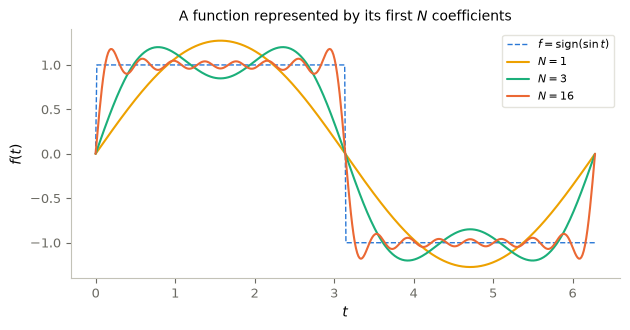

In [3]:
# A function -> its Fourier coefficients.  f(t) = sign(sin t) is odd, so only
# sines appear:  a_k = (1/pi) int_0^{2pi} f(t) sin(kt) dt = 4/(pi k) for k odd.
t_grid = np.linspace(0, 2 * np.pi, 400)
coeffs = np.array([2 * (1 - (-1) ** k) / (np.pi * k) for k in range(1, 17)])
print("first Fourier coefficients =", np.round(coeffs[:5], 3))

fig, ax = P.panels(figsize=(6.4, 3.4))
ax.plot(t_grid, np.sign(np.sin(t_grid)), color=P.BLUE, ls="--", lw=1, label=r"$f = \mathrm{sign}(\sin t)$")
for N, color in [(1, P.YELLOW), (3, P.AQUA), (16, P.ORANGE)]:
    partial = sum(coeffs[k - 1] * np.sin(k * t_grid) for k in range(1, N + 1))
    ax.plot(t_grid, partial, color=color, lw=1.5, label=f"$N = {N}$")
P.label(ax, "$t$", "$f(t)$", title=r"A function represented by its first $N$ coefficients")
plt.show()

## 4. Models

### Linear regression

The simplest ansatz: affine functions of a scalar input,

$$f_{w,b}(x) = w x + b,$$

with the squared loss, whose average is the **mean squared error (MSE)**: $F(w,b)=\frac1N\sum_i(wx_i+b-y_i)^2$.

**Code and plot.** Generate noisy points around a "true" line $y=2x-1+\varepsilon$, $\varepsilon\sim\mathcal N(0,0.5^2)$, and solve the fit in closed form.

closed form:  w = 1.992,  b = -0.957   (true: w = 2, b = -1)


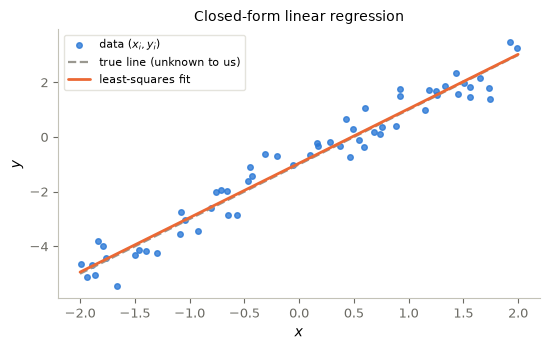

In [4]:
w_true, b_true, n = 2.0, -1.0, 60
x = rng.uniform(-2, 2, size=n)
y = w_true * x + b_true + 0.5 * rng.standard_normal(n)

# Linear regression is special: F is a convex quadratic, so grad F = 0 is solvable exactly.
# Stacking X = [x 1] and theta = (w, b), the normal equations read X^T X theta = X^T y.
X = np.stack([x, np.ones(n)], axis=1)          # design matrix, shape (n, 2)
theta_hat = np.linalg.solve(X.T @ X, X.T @ y)
w_hat, b_hat = theta_hat
print(f"closed form:  w = {w_hat:.3f},  b = {b_hat:.3f}   (true: w = 2, b = -1)")

xs = np.linspace(-2, 2, 100)
fig, ax = P.panels(figsize=(5.6, 3.6))
ax.scatter(x, y, color=P.BLUE, alpha=0.8, s=16, label="data $(x_i, y_i)$")
ax.plot(xs, w_true * xs + b_true, color=P.GREY, ls="--", label="true line (unknown to us)")
ax.plot(xs, w_hat * xs + b_hat, color=P.ORANGE, lw=2, label="least-squares fit")
P.label(ax, "$x$", "$y$", title="Closed-form linear regression")
plt.show()

### Neural networks

Linear models can only represent linear relationships. A **neural network** stacks affine maps with elementwise nonlinearities. The simplest case, a one-hidden-layer network of width $P$:

$$
\hat y(x;w)=\sum_{j=1}^Pc_j\,\sigma(a_j\cdot x+b_j),\qquad w=(a_1,b_1,c_1,\dots,a_P,b_P,c_P),
$$

where $\sigma$ is an **activation function** applied componentwise. Each term is a **neuron** (inner weights $a_j$, bias $b_j$, outer weight $c_j$); deeper networks compose such layers. Without $\sigma$ the composition of affine maps would collapse to a single affine map — the nonlinearity is what buys expressiveness.

> **Universal approximation ([Cybenko, 1989](https://doi.org/10.1007/BF02551274); [Hornik, 1991](https://doi.org/10.1016/0893-6080(91)90009-T); informal).** For any continuous $g$ on a compact set and any $\varepsilon>0$, there is a one-hidden-layer network $\hat y(\cdot;w)$ with $\|\hat y(\cdot;w)-g\|_\infty<\varepsilon$, provided the activation satisfies the theorem's assumptions (for example, a continuous sigmoidal activation) and the width $P$ is large enough.

The theorem says such weights *exist* — finding them means minimizing the loss, which is §5.

**Code and plot.** Three activation functions; notice where each one is nonlinear.

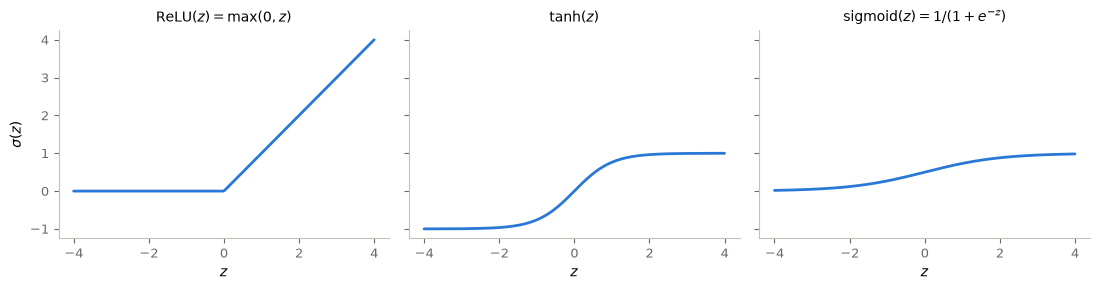

In [5]:
z = torch.linspace(-4, 4, 200)
fig, axes = P.panels(3, size=(3.7, 3.0), sharey=True)
for ax, fn, name in [(axes[0], torch.relu, "ReLU$(z) = \\max(0, z)$"),
                     (axes[1], torch.tanh, "tanh$(z)$"),
                     (axes[2], torch.sigmoid, "sigmoid$(z) = 1/(1+e^{-z})$")]:
    ax.plot(z, fn(z), color=P.BLUE, lw=2)
    P.label(ax, "$z$", title=name)
axes[0].set_ylabel(r"$\sigma(z)$")
plt.show()

### Classification: logits, softmax and cross-entropy

So far the output $\hat y$ was a real number. For **classification** into $C$ classes the network outputs *logits* $z=\hat y(x;w)\in\mathbb R^C$, turned into class probabilities by the **softmax**:

$$p_c = \frac{e^{z_c}}{\sum_{c'} e^{z_{c'}}}, \qquad c = 1, \dots, C.$$

The loss is the **cross-entropy**, the negative log-likelihood of the true class:

$$\ell(z, y) = -\log p_y = -z_y + \log \sum_{c} e^{z_c}.$$

Minimizing it is exactly maximum likelihood estimation. Only the last layer and the loss change; the training of §5 is the same for both tasks.

## 5. Training

### Gradient descent

For neural networks there is no closed-form solution — but we can always follow the negative gradient downhill:

$$w_{k+1} = w_k - \eta \, \nabla F(w_k),$$

where $\eta > 0$ is the **learning rate** (step size). For the linear model the gradient can be computed by hand: $\partial F/\partial w=\frac2N\sum_i(wx_i+b-y_i)x_i$ and $\partial F/\partial b=\frac2N\sum_i(wx_i+b-y_i)$.

**Code and animation.** Follow the parameter updates on the loss landscape over the $(w,b)$-plane.

In [6]:
def loss_wb(w, b):
    return np.mean((w * x + b - y) ** 2)

def gradient_wb(w, b):
    r = w * x + b - y                      # residuals
    return 2 * np.mean(r * x), 2 * np.mean(r)

eta, steps = 0.1, 60
w, b = -1.5, 2.0
path = [(w, b, loss_wb(w, b))]
for k in range(steps):
    gw, gb = gradient_wb(w, b)
    w, b = w - eta * gw, b - eta * gb
    path.append((w, b, loss_wb(w, b)))
path = np.array(path)
print(f"gradient descent:  w = {w:.3f},  b = {b:.3f}   (closed form: {w_hat:.3f}, {b_hat:.3f})")

W, B = np.meshgrid(np.linspace(-2, 4, 120), np.linspace(-2.5, 2.5, 120))
Z = np.array([[loss_wb(wi, bi) for wi in W[0]] for bi in B[:, 0]])
contours = lambda ax: P.contour_path(ax, W, B, Z, optimum=(w_hat, b_hat),
                                     optimum_label=r"optimum $\hat\theta$")
P.animate_trajectory(path[:, :2], decorate=contours, figsize=(6.5, 5), equal=False, ticks=True,
                     xlabel="$w$", ylabel="$b$",
                     title=lambda k: rf"Gradient descent on $F(w,b)$: step {k}, $F = {path[k, 2]:.3f}$")

gradient descent:  w = 1.992,  b = -0.957   (closed form: 1.992, -0.957)


The step size matters: for this quadratic loss, GD converges from every start if and only if $0<\eta<2/\lambda_{\max}(\nabla^2F)$ — too small creeps, too large diverges. In deep learning the learning rate is the most important **hyperparameter**, and the thresholds are no longer computable in advance.

### Automatic differentiation

We computed $\nabla F$ by hand — hopeless for a network with millions of parameters. **Automatic differentiation (autodiff)** computes *exact* gradients (up to floating-point error) of any function built from differentiable operations, at roughly the cost of one extra function evaluation. Every computation is a **graph** of elementary operations, and the chain rule composes their derivatives. **Reverse-mode** autodiff — **backpropagation** — traverses the graph from the output backwards: one backward pass yields $\partial F/\partial w_j$ for **all** parameters simultaneously. It is the discrete version of the adjoint method of optimal control.

In PyTorch: mark a tensor with `requires_grad=True`, compute, then call `.backward()`.

**Code and check.** Differentiate one scalar function and compare autodiff with the analytic derivative.

In [7]:
# f(x) = sin(x^2) * exp(-x);   analytic derivative: f'(x) = (2x cos(x^2) - sin(x^2)) e^{-x}
x0 = torch.tensor(1.3, requires_grad=True)
f = torch.sin(x0 ** 2) * torch.exp(-x0)   # forward pass (builds the graph)
f.backward()                              # backward pass (chain rule)

analytic = (2 * x0 * torch.cos(x0 ** 2) - torch.sin(x0 ** 2)) * torch.exp(-x0)
f_np = lambda t: np.sin(t ** 2) * np.exp(-t)
h = 1e-5
print(f"autograd:           {x0.grad.item():.10f}")
print(f"analytic:           {analytic.item():.10f}")
print(f"finite differences: {(f_np(1.3 + h) - f_np(1.3 - h)) / (2 * h):.10f}")

autograd:           -0.3548634648
analytic:           -0.3548634648
finite differences: -0.3548635744


Autodiff is **not** numerical differentiation (no step size $h$, no truncation error) and **not** symbolic differentiation (no expression swell) — it evaluates the chain rule numerically on the graph.

### Backpropagation: the chain rule on the computational graph

Take a two-layer model $f_w = \mathcal{A}_2 \circ \sigma \circ \mathcal{A}_1$ with affine maps $\mathcal{A}_\ell(u) = W_\ell u + b_\ell$, and a loss $\mathcal{L} = \ell(\hat y, y)$. The forward pass is a chain:

$$x \;\xrightarrow{\ \mathcal{A}_1\ }\; z_1 \;\xrightarrow{\ \sigma\ }\; h \;\xrightarrow{\ \mathcal{A}_2\ }\; \hat y \;\xrightarrow{\ \ell(\cdot,\, y)\ }\; \mathcal{L} .$$

Reverse-mode autodiff walks this chain backwards, from $\mathcal{L}$ to each parameter:

$$\frac{\partial \mathcal{L}}{\partial W_2}
 = \underbrace{\frac{\partial \mathcal{L}}{\partial \hat y}}_{\text{from } \ell}\,
   \frac{\partial \hat y}{\partial W_2},
\qquad
\frac{\partial \mathcal{L}}{\partial W_1}
 = \frac{\partial \mathcal{L}}{\partial \hat y}\,
   \frac{\partial \hat y}{\partial h}\,
   \frac{\partial h}{\partial z_1}\,
   \frac{\partial z_1}{\partial W_1}.$$

The point is the **shared prefix**. The factor $\partial \mathcal{L}/\partial \hat y$ is computed once and reused by every layer; going one layer deeper appends a single Jacobian-vector product to a quantity that already exists. Because $\mathcal{L}$ is *scalar*, each intermediate derivative has the same shape as the tensor it differentiates, so the full gradient costs a small multiple of a forward pass. Forward mode propagates $\partial(\cdot)/\partial w_j$ *forwards* instead, and costs one pass **per parameter**: for scalar losses of many parameters, reverse mode wins by a factor of $D$, which is why backpropagation is *the* algorithm of deep learning.

**Code and check.** PyTorch records the chain as it runs: walk the recorded graph backwards from the loss.

In [8]:
d, d_h, d_out = 3, 4, 2
x_g, y_g = torch.randn(1, d), torch.randn(1, d_out)
W1 = torch.randn(d, d_h, requires_grad=True)
W2 = torch.randn(d_h, d_out, requires_grad=True)

z1 = x_g @ W1                    # A_1
h_g = torch.relu(z1)             # sigma
y_hat = h_g @ W2                 # A_2
Lg = ((y_hat - y_g) ** 2).sum()  # loss

node = Lg.grad_fn                # walk the recorded graph backwards from the loss
while node is not None:
    print("  ", type(node).__name__)
    node = node.next_functions[0][0] if node.next_functions else None

Lg.backward()                    # one pass fills in every gradient
print(f"dL/dW1: {tuple(W1.grad.shape)},  dL/dW2: {tuple(W2.grad.shape)}")

   SumBackward0
   PowBackward0
   SubBackward0
   MmBackward0
   ReluBackward0
   MmBackward0
dL/dW1: (3, 4),  dL/dW2: (4, 2)


### Fitting a nonlinear function

Target: $g(x) = \sin(2\pi x)$ on $[-1, 1]$, observed with noise. We build a small MLP with `nn.Sequential` and train it with the loop that *every* PyTorch training script follows:

```
for each step:  forward pass → loss → zero grads → backward pass → optimizer step
```

Instead of plain GD we use **Adam** ([Kingma and Ba, 2014](https://arxiv.org/abs/1412.6980)), a variant with per-parameter adaptive step sizes.

**Code and plot.** Train the network and watch its prediction improve at a few checkpoints.

epoch    0:  MSE = 0.5687


epoch  100:  MSE = 0.0645


epoch  500:  MSE = 0.0093


epoch 2000:  MSE = 0.0091


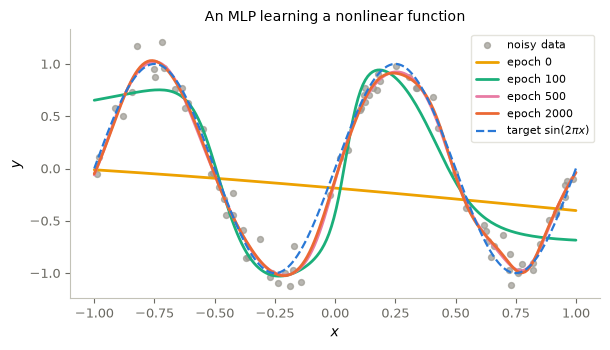

In [9]:
n_reg = 80
x_reg = rng.uniform(-1, 1, size=(n_reg, 1))
y_reg = np.sin(2 * np.pi * x_reg) + 0.1 * rng.standard_normal((n_reg, 1))
xt_reg = torch.tensor(x_reg, dtype=torch.float32)
yt_reg = torch.tensor(y_reg, dtype=torch.float32)

model = nn.Sequential(          # 1 -> 32 -> 32 -> 1 MLP
    nn.Linear(1, 32), nn.Tanh(),
    nn.Linear(32, 32), nn.Tanh(),
    nn.Linear(32, 1),
)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

xs_t = torch.linspace(-1, 1, 200).reshape(-1, 1)
snapshots = {}
for epoch in range(2001):
    y_pred = model(xt_reg)           # forward pass
    L = loss_fn(y_pred, yt_reg)      # training loss
    optimizer.zero_grad()            # reset accumulated gradients
    L.backward()                     # backprop
    optimizer.step()                 # parameter update
    if epoch in (0, 100, 500, 2000):
        with torch.no_grad():
            snapshots[epoch] = model(xs_t).numpy()
        print(f"epoch {epoch:4d}:  MSE = {L.item():.4f}")

fig, ax = P.panels(figsize=(6.2, 3.6))
ax.scatter(x_reg, y_reg, color=P.GREY, s=18, alpha=0.7, label="noisy data")
for (epoch, pred), color in zip(snapshots.items(), [P.YELLOW, P.AQUA, P.MAGENTA, P.ORANGE]):
    ax.plot(xs_t, pred, color=color, lw=2, label=f"epoch {epoch}")
ax.plot(xs_t, np.sin(2 * np.pi * xs_t.numpy()), color=P.BLUE, ls="--",
        label=r"target $\sin(2\pi x)$")
P.label(ax, "$x$", "$y$", title="An MLP learning a nonlinear function")
plt.show()

### Mini-batches and stochastic gradients

With large datasets, computing $\nabla F$ over *all* $N$ points per step is wasteful. **Stochastic gradient descent (SGD)** uses a random **mini-batch** $B \subset \{1,\dots,N\}$ per step:

$$w_{k+1} = w_k - \eta \cdot \frac{1}{|B|} \sum_{i \in B} \nabla_w\, \ell\big(\hat y(x_i;w), y_i\big),$$

an *unbiased* estimate of the full gradient that is much cheaper — this is what PyTorch's `DataLoader` is for. The price is gradient noise.

## 6. Laboratory: polynomial regression

The regression dataset of this laboratory consists of $N=60$ samples $y_i=f(x_i)+\text{noise}$ with $x_i$ uniform on $[-1,1]$, standard deviation $0.3$ for the noise, and a smooth function $f$ that the learner does not know. **Before any model is fitted**, the indices are split once into a training set (36 samples), a validation set (12) and a test set (12). The roles are fixed in advance:

- the **training set** fits the coefficients of each candidate model;
- the **validation set** chooses among the candidates (here: the degree);
- the **test set** is put aside and evaluated after the choice, to report the performance; no decision may depend on it.

The candidates are least-squares polynomials of degree $0,\dots,15$, written in the Legendre basis for numerical stability. The selection function below receives training and validation data only; it has no access to the test set.

> **A disclosure about this test set.** While this example was designed, prototype runs also displayed test errors. The 12-sample test value below is therefore *development data*, not a fully independent evaluation. The independent check is a **fresh holdout** of 200 samples, specified in advance and evaluated once, in the same cell.

**Code and plot.** Fit all degrees on the training set, select on the validation set, and only then evaluate.

degree:          [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
training MSE:    [1.007 0.961 0.906 0.849 0.525 0.116 0.104 0.075 0.075 0.075 0.074 0.067
 0.066 0.065 0.059 0.054]
validation MSE:  [1.3340000e+00 1.2660000e+00 9.9100000e-01 8.9500000e-01 4.8300000e+00
 2.4900000e+00 6.8830000e+00 2.9700000e-01 4.8300000e-01 1.9800000e-01
 1.8910000e+01 1.5660600e+02 5.0240000e+00 3.9058500e+02 1.5138419e+04
 4.5028700e+03]
degree selected on the validation set: 9


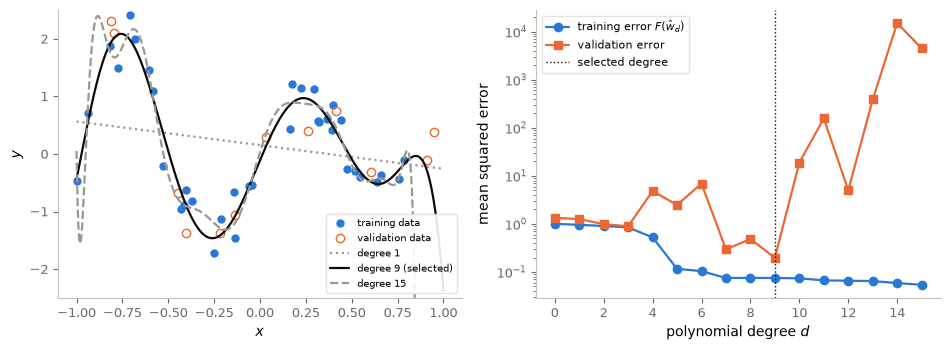

In [10]:
target_fn = lambda t: np.sin(2 * np.pi * t) * np.exp(-t)      # unknown to the learner
noise_level = 0.3

def regression_data(generator, n=60):
    xs = generator.uniform(-1, 1, n)
    return xs, target_fn(xs) + noise_level * generator.standard_normal(n)

polynomial_features = lambda xs, d: np.polynomial.legendre.legvander(xs, d)
least_squares_fit = lambda A, ys: np.linalg.lstsq(A, ys, rcond=None)[0]
mse = lambda A, w, ys: float(np.mean((A @ w - ys) ** 2))

rng9 = np.random.default_rng(3)                               # the regression data have their own stream
x9, y9 = regression_data(rng9)                                # 60 noisy samples
perm = rng9.permutation(60)                                   # split BEFORE any fitting
train_idx, val_idx, test_idx = perm[:36], perm[36:48], perm[48:]
x_tr, y_tr, x_val, y_val = x9[train_idx], y9[train_idx], x9[val_idx], y9[val_idx]
degrees = np.arange(16)

def select_degree(x_tr, y_tr, x_val, y_val, degrees):
    # Fits every candidate on the TRAINING data and chooses the degree on the VALIDATION data.
    # There is deliberately no test argument.
    fits = [least_squares_fit(polynomial_features(x_tr, d), y_tr) for d in degrees]
    train_err = np.array([mse(polynomial_features(x_tr, d), w, y_tr) for d, w in zip(degrees, fits)])
    val_err = np.array([mse(polynomial_features(x_val, d), w, y_val) for d, w in zip(degrees, fits)])
    return int(degrees[np.argmin(val_err)]), fits, train_err, val_err

selected_degree, fits, train_mse, val_mse = select_degree(x_tr, y_tr, x_val, y_val, degrees)
print("degree:         ", degrees)
print("training MSE:   ", np.round(train_mse, 3))
print("validation MSE: ", np.round(val_mse, 3))
print("degree selected on the validation set:", selected_degree)

grid = np.linspace(-1, 1, 400)
fig, (ax1, ax2) = P.panels(2, size=(4.8, 3.6))
ax1.plot(x_tr, y_tr, "o", color=P.BLUE, ms=5, label="training data")
ax1.plot(x_val, y_val, "o", mfc="none", color=P.ORANGE, ms=6, label="validation data")
for dd, style in ((1, ":"), (selected_degree, "-"), (15, "--")):
    ax1.plot(grid, polynomial_features(grid, dd) @ fits[dd], style,
             color=P.INK if dd == selected_degree else P.GREY, lw=1.6,
             label=f"degree {dd}" + (" (selected)" if dd == selected_degree else ""))
P.label(ax1, "$x$", "$y$", ylim=(-2.5, 2.5), legend={"fontsize": 7, "loc": "lower right"})
ax2.semilogy(degrees, train_mse, "o-", color=P.BLUE, label="training error $F(\\hat w_d)$")
ax2.semilogy(degrees, val_mse, "s-", color=P.ORANGE, label="validation error")
ax2.axvline(selected_degree, color=P.INK, ls=":", lw=1, label="selected degree")
P.label(ax2, "polynomial degree $d$", "mean squared error")
plt.show()

The training error decreases at every degree (the classes are nested); the validation error first decreases and then explodes. Degree 1 *underfits*, missing the shape of $f$; degree 15 *overfits*, bending towards noisy training points and oscillating between them (its curve leaves the vertical range near $x=\pm1$). The validation minimum, here at degree 9, selects the model. A small training error is no evidence of a good model: fitting is not learning. The test samples are not shown: they are not used before the final evaluation, which comes now.

In [11]:
# Evaluation after the degree has been selected (no decision depends on these numbers).
w_selected = fits[selected_degree]
x_test, y_test9 = x9[test_idx], y9[test_idx]
test_mse_dev = mse(polynomial_features(x_test, selected_degree), w_selected, y_test9)
holdout_rng = rng9.spawn(1)[0]           # one child stream: independent of every draw of rng9
x_new, y_new = regression_data(holdout_rng, n=200)    # fresh holdout (see the disclosure)
holdout_mse = mse(polynomial_features(x_new, selected_degree), w_selected, y_new)

print(f"selected degree {selected_degree}: training MSE {train_mse[selected_degree]:.3f},"
      f" validation MSE {val_mse[selected_degree]:.3f}")
print(f"  12-sample test split (development data, exposed during design): MSE {test_mse_dev:.3f}")
print(f"  fresh holdout of 200 samples (pre-specified, single evaluation):  MSE {holdout_mse:.3f}")
print("index sets disjoint:", not (set(train_idx) & set(val_idx) or set(train_idx) & set(test_idx)
                                   or set(val_idx) & set(test_idx)))

selected degree 9: training MSE 0.075, validation MSE 0.198
  12-sample test split (development data, exposed during design): MSE 0.155
  fresh holdout of 200 samples (pre-specified, single evaluation):  MSE 0.185
index sets disjoint: True


## 7. Overfitting and the generalization gap

The laboratory shows the two failures of every learning problem. **Underfitting:** the class cannot represent the structure of the data, and training and validation errors are both large. **Overfitting:** the class is rich enough to fit the noise of the training sample, so the training error is small and the error on new data large.

**The training error always improves with complexity.** If $\mathcal H_d\subset\mathcal H_{d+1}$, as for polynomials of increasing degree, then $\min_{\mathcal H_{d+1}}F\le\min_{\mathcal H_d}F$: a minimum over more candidates cannot be larger. A monotone quantity cannot tell when to stop; the population risk is not monotone. §8 shows that the training error of a fitted model is moreover *systematically* optimistic.

## 8. Selection bias: why the training error is optimistic

Let $S=\{(x_i,y_i)\}_{i=1}^N$ be a sample of $N$ independent draws from $\rho$, and write $F_S$ for the empirical risk computed on $S$.

> **Proposition 1 (unbiasedness for a fixed model).**
> *Assumptions:* the parameter $w$ is fixed, and does not depend on $S$; $\mathcal R(w)<\infty$.
>
> *Conclusion:* $\mathbb E_S\,F_S(w)=\mathcal R(w)$.
>
> *Interpretation:* for a model chosen *before* seeing the data, the average loss on the data is an honest estimate of the risk.

*Proof.* By linearity of expectation, $\mathbb E_S F_S(w)=\frac1N\sum_i\mathbb E\,\ell(\hat y(x_i;w),y_i)=\frac1N\sum_i\mathcal R(w)=\mathcal R(w)$, since each $(x_i,y_i)$ has law $\rho$ and $w$ does not depend on it. $\square$

**What goes wrong for a fitted model.** The estimate $\hat w(S)$ *depends on the sample*, while the proof used that $w$ is the same for every draw of $S$; so $\hat w(S)$ cannot be substituted, and in general $\mathbb E_S F_S(\hat w(S))\ne\mathbb E_S\mathcal R(\hat w(S))$. The data have been used twice, to choose $\hat w$ and to judge it: **selection bias**. Its sign depends on how $\hat w$ is chosen. For empirical risk minimization it is optimistic:

> **Proposition 2 (optimism of empirical risk minimization).**
> *Assumptions:* $\hat w(S)$ minimizes $F_S$ over a class $\mathcal H$ for every sample $S$; the population risk has a minimizer $w_{\mathcal H}$ over $\mathcal H$; the expectations are finite.
>
> *Conclusion:*
> $$\mathbb E_S\,F_S\big(\hat w(S)\big)\;\le\;\mathcal R(w_{\mathcal H})\;\le\;\mathbb E_S\,\mathcal R\big(\hat w(S)\big).$$
>
> *Interpretation:* on average, the fitted model's training error lies below the best risk in the class, and its risk above it.

*Proof.* For every sample, $F_S(\hat w(S))\le F_S(w_{\mathcal H})$, because $\hat w(S)$ minimizes $F_S$. Taking expectations and applying Proposition 1 to the fixed parameter $w_{\mathcal H}$ gives the first inequality. For every sample, $\mathcal R(w_{\mathcal H})\le\mathcal R(\hat w(S))$, because $w_{\mathcal H}$ minimizes $\mathcal R$ over $\mathcal H$; taking expectations gives the second. $\square$

Without such hypotheses no sign can be claimed (Exercise 3 builds a fitting rule with a pessimistic training error).

**Code and plot.** The regression data are synthetic, so their population risk can be computed by quadrature, an oracle no real application has. Draw 300 training samples of size 36, fit every degree on each, and average.

degree:                   [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
average training error:   [0.905 0.734 0.627 0.509 0.462 0.136 0.099 0.075 0.069 0.066 0.063 0.06
 0.058]
best risk in the class:   [0.941 0.782 0.691 0.603 0.579 0.17  0.134 0.098 0.091 0.09  0.09  0.09
 0.09 ]
average risk of the fit:  [  0.969   0.824   0.751   0.722   0.852   0.27    0.329   0.303   0.287
   4.885  11.966  42.13  195.464]
Proposition 2 holds for every degree: True


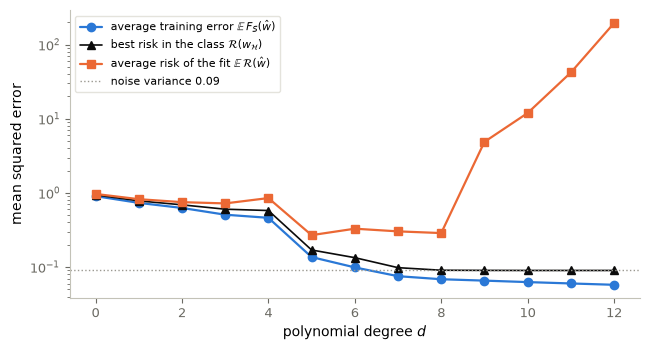

In [12]:
nodes, weights = np.polynomial.legendre.leggauss(200)         # quadrature for the oracle risk
def population_risk(predict):
    # R = E[(g(x) - y)^2] = E[(g - f)^2] + noise^2, with x uniform on [-1, 1]
    return 0.5 * np.sum(weights * (predict(nodes) - target_fn(nodes)) ** 2) + noise_level ** 2

n_rep, degrees_sb = 300, np.arange(13)
best_in_class = np.empty(len(degrees_sb))
for d in degrees_sb:
    # w_H: least-squares projection of the target in L^2 of the uniform law on [-1, 1]
    root_w = np.sqrt(weights)
    w_H = least_squares_fit(root_w[:, None] * polynomial_features(nodes, d), root_w * target_fn(nodes))
    best_in_class[d] = population_risk(lambda t: polynomial_features(t, d) @ w_H)

train_err_rep = np.empty((n_rep, len(degrees_sb)))
risk_rep = np.empty((n_rep, len(degrees_sb)))
for r in range(n_rep):
    xs, ys = regression_data(rng, n=36)                       # a fresh training sample
    for d in degrees_sb:
        w_fit = least_squares_fit(polynomial_features(xs, d), ys)
        train_err_rep[r, d] = mse(polynomial_features(xs, d), w_fit, ys)
        risk_rep[r, d] = population_risk(lambda t: polynomial_features(t, d) @ w_fit)
avg_train, avg_risk = train_err_rep.mean(axis=0), risk_rep.mean(axis=0)
print("degree:                  ", degrees_sb)
print("average training error:  ", np.round(avg_train, 3))
print("best risk in the class:  ", np.round(best_in_class, 3))
print("average risk of the fit: ", np.round(avg_risk, 3))
print("Proposition 2 holds for every degree:",
      bool(np.all(avg_train <= best_in_class) and np.all(best_in_class <= avg_risk)))

fig, ax = P.panels(figsize=(6.6, 3.6))
ax.semilogy(degrees_sb, avg_train, "o-", color=P.BLUE,
            label=r"average training error $\mathbb{E}\,F_S(\hat w)$")
ax.semilogy(degrees_sb, best_in_class, "^-", color=P.INK, lw=1.2,
            label=r"best risk in the class $\mathcal{R}(w_{\mathcal{H}})$")
ax.semilogy(degrees_sb, avg_risk, "s-", color=P.ORANGE,
            label=r"average risk of the fit $\mathbb{E}\,\mathcal{R}(\hat w)$")
ax.axhline(noise_level ** 2, color=P.GREY, ls=":", lw=1, label="noise variance $0.09$")
P.label(ax, "polynomial degree $d$", "mean squared error")
plt.show()

The curves are ordered as Proposition 2 says, at every degree. For large degrees the training error falls *below the noise variance* $0.3^2$ (dotted), which no predictor's risk can do: pure optimism. The average gap widens with the degree; richer classes contain better predictors, but with 36 samples the fit cannot find them, and its risk turns upward.

## 9. Training, validation and test sets

One level up, **the validation error of the selected model is also optimistic.** Given the training data, each candidate's validation error is unbiased for its risk (Proposition 1), but the selected candidate has the *smallest* one, and the expected minimum of unbiased estimates is at most the smallest of their expectations.

The **test set** repairs this. It is independent of the training and validation samples and plays no role in any choice, so for the test samples the selected model is a *fixed* model, and by Proposition 1 **the test error is an unbiased estimate of the risk of the selected model.** What matters is not how often the test set is evaluated but that **no decision depends on it**. As soon as a test result influences a choice (another degree, step size or stopping time, or even the design of the experiment), it has become a second validation set and its error is biased again.

| Set | Used to | Must not be used to |
|---|---|---|
| training | fit the parameters $w$ | judge the fitted model |
| validation | choose hyperparameters: degree, step size, stopping time, … | report final performance |
| test | report the performance, at the end | make any choice: no decision may depend on it |

**The protocol**: (1) split once, before any fitting, and record the index sets; (2) fit every candidate on the training set; (3) select on the validation set and record the selection; (4) evaluate the selected model once on the test set. We do **not** refit on training and validation data together; that variant must be decided in advance.

**One realization, not an average.** In one split the validation error at the selected degree can land above or below the test error: the optimism concerns averages, and with 12 validation samples one split's fluctuation dominates it (Exercise 5).

## 10. A classifier on held-out data

First, a **two-class point cloud**: 120 points in two Gaussian clouds, with a fixed train/validation/test split of 72/24/24. The cloud is almost linearly separable, which makes it a convenient test problem and a poor *demonstration* of what a network adds. So for the classifier demonstration we use a second, curved dataset — the **two moons** — which no linear model can separate, with the same discipline: train an MLP on 75% of the points with the cross-entropy of §4 and the mini-batch SGD of §5, and track the accuracy on the remaining 25%, which the training never sees.

**Code and plot.** Fix the point cloud and its split, generate the moons, train a small network, and inspect its decision boundary.

point cloud: (120, 2)  split: 72 / 24 / 24


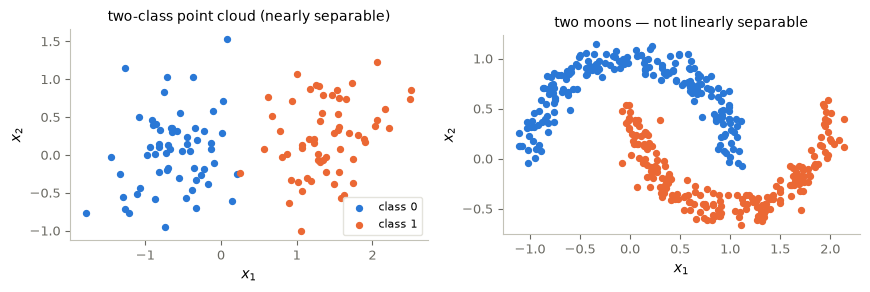

In [13]:
# The two-class point cloud and its fixed 72 / 24 / 24 split (later notebooks redraw it identically)
torch.manual_seed(0)                                   # the cloud is the first torch draw after this seed
X6 = torch.cat([torch.randn(60, 2) * 0.45 + torch.tensor([-0.6, 0.0]),
                torch.randn(60, 2) * 0.45 + torch.tensor([1.3, 0.3])]).numpy()
y6 = np.repeat([0.0, 1.0], 60)
idx6 = np.random.default_rng(0).permutation(120)
train6, val6, test6 = idx6[:72], idx6[72:96], idx6[96:]
print("point cloud:", X6.shape, " split:", len(train6), "/", len(val6), "/", len(test6))

def make_moons(n_per_class=200, noise=0.08):
    t = np.pi * rng.random(n_per_class)
    upper = np.stack([np.cos(t), np.sin(t)], axis=1)             # class 0
    lower = np.stack([1 - np.cos(t), 0.5 - np.sin(t)], axis=1)   # class 1
    Xm = np.concatenate([upper, lower]) + noise * rng.standard_normal((2 * n_per_class, 2))
    ym = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)]).astype(np.int64)
    return Xm.astype(np.float32), ym

X_moons, y_moons = make_moons()
perm_m = rng.permutation(len(X_moons))
tr_m, te_m = perm_m[:300], perm_m[300:]      # 75% train / 25% test

fig, (ax1, ax2) = P.panels(2, size=(4.4, 3.6))
for cls, color in ((0, P.BLUE), (1, P.ORANGE)):
    ax1.scatter(*X6[y6 == cls].T, color=color, s=18, label=f"class {int(cls)}")
    ax2.scatter(*X_moons[y_moons == cls].T, color=color, s=18)
P.label(ax1, "$x_1$", "$x_2$", title="two-class point cloud (nearly separable)", equal=True)
P.label(ax2, "$x_1$", "$x_2$", title="two moons — not linearly separable", equal=True)
plt.show()

final test accuracy: 100.0%


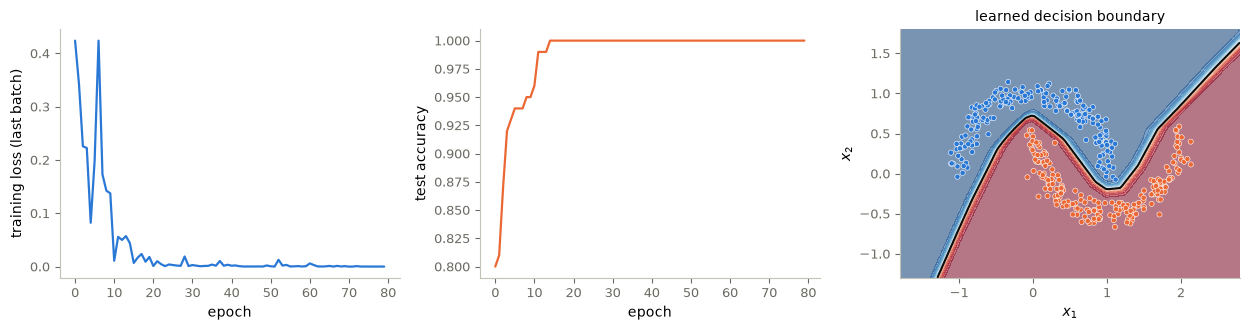

In [14]:
from torch.utils.data import DataLoader, TensorDataset

train_set = TensorDataset(torch.tensor(X_moons[tr_m]), torch.tensor(y_moons[tr_m]))
loader = DataLoader(train_set, batch_size=32, shuffle=True)
X_test_m, y_test_m = torch.tensor(X_moons[te_m]), torch.tensor(y_moons[te_m])

clf = nn.Sequential(                 # 2 -> 16 -> 16 -> 2 (logits)
    nn.Linear(2, 16), nn.ReLU(),
    nn.Linear(16, 16), nn.ReLU(),
    nn.Linear(16, 2),
)
optimizer = torch.optim.Adam(clf.parameters(), lr=1e-2)
loss_fn = nn.CrossEntropyLoss()      # softmax + negative log-likelihood in one

history = []
for epoch in range(80):
    for xb, yb in loader:            # one pass over the mini-batches = one epoch
        L = loss_fn(clf(xb), yb)
        optimizer.zero_grad()
        L.backward()
        optimizer.step()
    with torch.no_grad():            # evaluate on held-out data (no gradients needed)
        test_acc = (clf(X_test_m).argmax(dim=1) == y_test_m).float().mean().item()
        history.append((L.item(), test_acc))
print(f"final test accuracy: {history[-1][1]:.1%}")

g1, g2 = np.meshgrid(np.linspace(-1.8, 2.8, 120), np.linspace(-1.3, 1.8, 120))
grid_t = torch.tensor(np.stack([g1.ravel(), g2.ravel()], axis=1), dtype=torch.float32)
with torch.no_grad():
    probs = torch.softmax(clf(grid_t), dim=1)[:, 1].reshape(g1.shape).numpy()

history_arr = np.array(history)
fig, axes = P.panels(3, size=(4.2, 3.4))
P.curves(axes[0], None, history_arr[:, 0], xlabel="epoch", ylabel="training loss (last batch)")
P.curves(axes[1], None, (history_arr[:, 1], P.ORANGE), xlabel="epoch", ylabel="test accuracy")
P.decision_boundary(axes[2], g1, g2, probs, X_moons, y_moons, title="learned decision boundary", cbar=False)
plt.show()

The network reaches high accuracy on points it has never seen: it has *learned* the moons, not memorized them. The decision boundary bends between the two classes.

## 11. Why the loss is not convex

**Relabelling the neurons** of the one-hidden-layer network of §4 does not change the function $\hat y(\cdot;w)$, so every permutation of a global minimizer is again a global minimizer. Symmetry alone proves nothing: a convex function can be symmetric. What proves nonconvexity is a failure of Jensen's inequality $F(\tfrac12(w+w'))\le\tfrac12F(w)+\tfrac12F(w')$. The cell below builds one: the labels are the outputs of a fixed two-neuron network, so that network and its relabelling both have loss $0$, while the midpoint of the two parameter vectors, where the two neurons coincide, has positive loss. This shows that the loss *can* be nonconvex; it is a counterexample, not a theorem about every architecture and dataset.

**Code and check.** Evaluate the loss at a minimizer, at its relabelling, and at their midpoint.

In [15]:
def one_hidden_layer(xs, a, b, c):
    # yhat(x) = sum_j c_j tanh(a_j . x + b_j);  xs: (M, d), a: (P, d), b and c: (P,)
    return np.tanh(xs @ a.T + b) @ c

a_nn, b_nn, c_nn = (np.array([[1.0, -0.5], [-0.8, 1.2]]), np.array([0.3, -0.2]),
                    np.array([1.0, -0.7]))                    # two neurons
y_syn = one_hidden_layer(X6, a_nn, b_nn, c_nn)                # labels produced by this very network
loss_nn = lambda a, b, c: np.mean((one_hidden_layer(X6, a, b, c) - y_syn) ** 2)
swap = np.array([1, 0])                                       # relabel the two neurons
loss_w = loss_nn(a_nn, b_nn, c_nn)
loss_perm = loss_nn(a_nn[swap], b_nn[swap], c_nn[swap])
loss_mid = loss_nn((a_nn + a_nn[swap]) / 2, (b_nn + b_nn[swap]) / 2, (c_nn + c_nn[swap]) / 2)
print(f"loss at w: {loss_w:.1e};  at its relabelling: {loss_perm:.1e};  at the midpoint: {loss_mid:.4f}")
print("Jensen's inequality fails (midpoint above the average of the endpoints):",
      loss_mid > (loss_w + loss_perm) / 2)

loss at w: 0.0e+00;  at its relabelling: 5.9e-33;  at the midpoint: 1.2118
Jensen's inequality fails (midpoint above the average of the endpoints): True


## 12. Control ↔ ML

- **Feedback and reinforcement learning** (a mathematical analogy). Reinforcement learning is "learning based on feedback", the word used for control laws that depend on the observed state. A feedback law is *designed* from a model; a policy is *learned* from rewards. The structure is shared, the mathematics differs.
- **Robustness is not generalization** (a contrast): robustness of controllability concerns one known system, generalization new samples from an unknown law.
- **Training is minimization** (a direct connection). Minimizing $F$ is an optimization problem like those of optimal control, solved by the same gradient methods; what is new is that $F$ is an average over many samples.
- **Fitting data by a control** (a forward connection). Classification can be posed as a simultaneous control problem; steering the training points is fitting, and whether new points are classified correctly is generalization, judged with the protocol of §9.

## 13. Federated learning: when the data cannot be pooled

*Optional.*

In federated learning the data stay with many parties, because sending them is too costly or too sensitive. Learning alone on local data is not a solution either: a local dataset may be too small, which leads to overfitting, or biased, not representative of the target distribution. The generic protocol is iterative: *initialize a model; each party updates it on its local data; the parties share their updates; a server aggregates them and sends the result back*. Unlike distributed learning, the local data are typically **not i.i.d.** and imbalanced.

**Code and plot.** Federated averaging on the training data of §6 split among three parties, with polynomials of degree 5 (a lower degree than in §6, so that local gradient descent converges in a few hundred steps). Each round, every party performs 10 gradient-descent steps on its own data, starting from the current global model, and the server averages the three results. We compare an *i.i.d.* split of the 36 samples with a *non-i.i.d.* split by the value of $x$, in which each party sees only one third of the interval. Scores are validation errors; the test set is not used.

pooled data (centralized least squares): validation MSE 2.490
i.i.d.      each party alone: validation MSE ['2.84', '5.68', '0.123'];  federated averaging: 2.589, |w_fed - w_central| = 0.133


non-i.i.d.  each party alone: validation MSE ['1.05e+08', '7.72e+04', '1.6e+07'];  federated averaging: 2.221, |w_fed - w_central| = 0.239


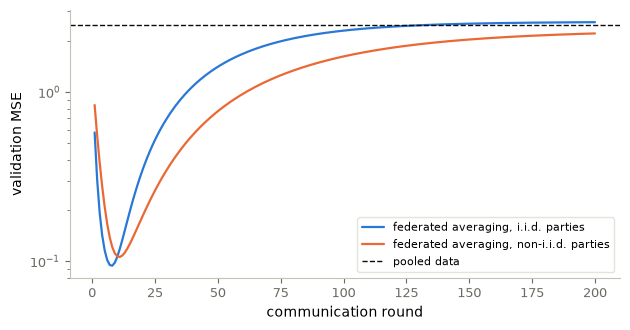

In [16]:
d_fed = 5
P_val_fed = polynomial_features(x_val, d_fed)
w_central = least_squares_fit(polynomial_features(x_tr, d_fed), y_tr)   # pooled-data model
parties = {"i.i.d.": [np.arange(len(x_tr))[k::3] for k in range(3)],
           "non-i.i.d.": np.array_split(np.argsort(x_tr), 3)}   # each party: one third of [-1, 1]

def fedavg(groups, rounds=200, local_steps=10):
    w = np.zeros(d_fed + 1)
    history = []
    for _ in range(rounds):
        updates = []
        for g in groups:                                        # local GD on each party's data
            A = polynomial_features(x_tr[g], d_fed)
            eta = 0.5 / np.linalg.eigvalsh(A.T @ A / len(g))[-1]
            v = w.copy()
            for _ in range(local_steps):
                v = v - eta * A.T @ (A @ v - y_tr[g]) / len(g)
            updates.append(v)
        w = np.mean(updates, axis=0)                            # the server averages
        history.append(mse(P_val_fed, w, y_val))
    return w, np.array(history)

print(f"pooled data (centralized least squares): validation MSE {mse(P_val_fed, w_central, y_val):.3f}")
fed_history = {}
for name, groups in parties.items():
    local = [least_squares_fit(polynomial_features(x_tr[g], d_fed), y_tr[g]) for g in groups]
    w_fed, fed_history[name] = fedavg(groups)
    print(f"{name:11s} each party alone: validation MSE "
          f"{[f'{mse(P_val_fed, w, y_val):.3g}' for w in local]};  "
          f"federated averaging: {fed_history[name][-1]:.3f}, "
          f"|w_fed - w_central| = {np.linalg.norm(w_fed - w_central):.3f}")

fig, ax = P.panels(figsize=(6.4, 3.4))
for (name, hist), color in zip(fed_history.items(), (P.BLUE, P.ORANGE)):
    ax.semilogy(np.arange(1, len(hist) + 1), hist, color=color,
                label=f"federated averaging, {name} parties")
ax.axhline(mse(P_val_fed, w_central, y_val), color=P.INK, ls="--", lw=1, label="pooled data")
P.label(ax, "communication round", "validation MSE")
plt.show()

With the non-i.i.d. split, each party alone produces a useless model: fitted on one third of the interval, it extrapolates wildly, as the printed validation errors show. Federated averaging reaches, in a few rounds, a model whose validation error is close to that of the pooled data, without any party sharing its samples. Its limit is not exactly the pooled least-squares model (the printed distance is not zero): with several local steps per round, the parties drift towards their own minimizers, and averaging does not cancel this exactly. This *client drift* is one of the reasons why federated optimization is a research field of its own.

## 14. A zoo of architectures

Changing the architecture changes only the family $\mathcal H=\{\hat y(\cdot;w)\}$; the dataset, the loss and the training loop stay the same. The standard architectures differ in **which structure of the input they build in**. Below is each one in its smallest form: the defining formula, its assumption, and a shape check in PyTorch.

### 14.1 Multilayer perceptron — no structure assumed

$$f_w = \mathcal{A}_L \circ \sigma \circ \cdots \circ \sigma \circ \mathcal{A}_1, \qquad \mathcal{A}_\ell(u) = W_\ell u + b_\ell.$$

The baseline of §4. The input is an unstructured vector in $\mathbb{R}^d$: permuting its coordinates (and the columns of $W_1$ with them) gives the same function, so an MLP has no notion of which inputs are *near* one another. It is a universal approximator already at $L = 2$, but the width must grow to make up for the missing structure.

In [17]:
d, d_h, d_out = 16, 32, 4
x_mlp = torch.randn(d)
mlp = nn.Sequential(nn.Linear(d, d_h), nn.ReLU(), nn.Linear(d_h, d_out))
print("MLP        ", tuple(x_mlp.shape), "->", tuple(mlp(x_mlp).shape),
      f"| {sum(p.numel() for p in mlp.parameters())} parameters")

MLP         (16,) -> (4,) | 676 parameters


### 14.2 Convolutional network — translation structure

For an image $x \in \mathbb{R}^{C_{\text{in}} \times H \times W}$ and a $k \times k$ kernel $K$,

$$(K \star x)(i, j) = \sum_{p,\, q} K(p, q)\, x(i - p,\ j - q).$$

The assumption is that **the same local pattern means the same thing wherever it occurs**. Formally, convolution is *translation-equivariant*: $K \star (T_v x) = T_v (K \star x)$ for a shift $T_v$. Hence the parameter count $C_{\text{out}} C_{\text{in}} k^2$ does not depend on the image size, whereas a dense layer needs $C_{\text{in}} H W \times C_{\text{out}} H W$.

In [18]:
x_img = torch.randn(3, 32, 32)                    # one RGB image
conv = nn.Conv2d(3, 8, kernel_size=3)             # 8 output channels
dense_equivalent = (3 * 32 * 32) * (8 * 30 * 30)  # what a fully connected layer would cost
print("CNN        ", tuple(x_img.shape), "->", tuple(conv(x_img).shape),
      f"| {sum(p.numel() for p in conv.parameters())} parameters",
      f"vs {dense_equivalent:,} for a dense layer")

CNN         (3, 32, 32) -> (8, 30, 30) | 224 parameters vs 22,118,400 for a dense layer


### 14.3 Recurrent network — a dynamical system in time

For a sequence $x_1, \dots, x_T$ with $x_t \in \mathbb{R}^{d}$ and hidden state $h_t \in \mathbb{R}^{d_h}$,

$$h_t = \sigma\big(W_h h_{t-1} + W_x x_t + b\big), \qquad \hat y_t = V h_t + c.$$

This is a **discrete dynamical system with a learned vector field**. The same parameters act at every step, so one network handles sequences of any length. Training unrolls the recursion (*backpropagation through time*). For $\mathcal{L} = \sum_{t=1}^T \ell(\hat y_t, y_t)$,

$$\frac{\partial \mathcal{L}}{\partial W_h}
 = \sum_{t=1}^{T} \sum_{k=1}^{t}
   \frac{\partial \ell_t}{\partial \hat y_t}\,
   \frac{\partial \hat y_t}{\partial h_t}\,
   \Bigg(\prod_{j=k+1}^{t} \frac{\partial h_j}{\partial h_{j-1}}\Bigg)\,
   \frac{\partial h_k}{\partial W_h}.$$

Each term carries a **product of up to $T$ Jacobians**. It decays geometrically when their norms stay below $1$ (vanishing gradients) and can blow up when they exceed it (exploding gradients). This motivates gated architectures (LSTM, GRU), gradient clipping and, in the continuous limit, the neural ODEs of §14.5.

RNN         (60, 1) -> (60, 8) | 88 parameters, shared over all 60 steps


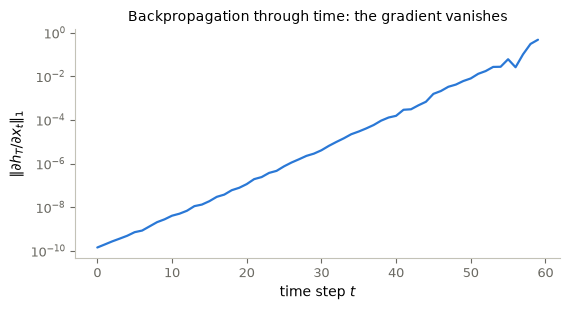

In [19]:
T_seq, d, d_h = 60, 1, 8
rnn = nn.RNN(d, d_h)
xs_seq = torch.randn(T_seq, d, requires_grad=True)
hs, _ = rnn(xs_seq)
hs[-1].sum().backward()           # sensitivity of the LAST state to every input

sensitivity = xs_seq.grad.abs().sum(dim=1)
print("RNN        ", tuple(xs_seq.shape), "->", tuple(hs.shape),
      f"| {sum(p.numel() for p in rnn.parameters())} parameters, shared over all {T_seq} steps")

fig, ax = P.panels(figsize=(5.8, 3.2))
P.curves(ax, range(T_seq), sensitivity, log="y", xlabel="time step $t$",
         ylabel=r"$\|\partial h_T / \partial x_t\|_1$",
         title="Backpropagation through time: the gradient vanishes")
plt.show()

Read the plot from right to left, the direction the gradient travels. The roughly straight line on the log axis is geometric decay: early inputs receive orders of magnitude less gradient than recent ones, too little to learn from.

### 14.4 Transformer — attention instead of locality

For $T$ tokens stacked as $X \in \mathbb{R}^{T \times d}$, with queries, keys and values $Q = X W_Q$, $K = X W_K$, $V = X W_V$,

$$\mathrm{Attn}(Q, K, V) = \mathrm{softmax}\!\left(\frac{Q K^\top}{\sqrt{d}}\right) V.$$

Each output row is a **convex combination of the value rows**, with weights computed from the data. Unlike a convolution, the neighborhood a token reads from is chosen per input. The map is *permutation-equivariant*, so word order must be injected by positional encodings. Every token reaches every other in one layer, at a cost of $\mathcal{O}(T^2)$ attention weights.

In [20]:
T_tok, d, n_heads = 10, 32, 4
X_tok = torch.randn(T_tok, d)
attn = nn.MultiheadAttention(d, n_heads)
out, weights = attn(X_tok, X_tok, X_tok)   # query = key = value: "self"-attention
print("Transformer", tuple(X_tok.shape), "->", tuple(out.shape),
      f"| attention matrix {tuple(weights.shape)},",
      f"rows sum to {weights.sum(-1).mean():.3f}")

Transformer (10, 32) -> (10, 32) | attention matrix (10, 10), rows sum to 1.000


### 14.5 Neural ODE — depth as continuous time

A residual block $h_{\ell+1} = h_\ell + f_w(h_\ell)$ is an explicit Euler step with $\Delta t = 1$. Letting the step size go to zero gives an initial value problem ([Chen et al., 2018](https://arxiv.org/abs/1806.07366)):

$$\frac{d h(t)}{d t} = f_w\big(h(t),\, t\big), \qquad h(0) = x, \qquad y = h(T).$$

Depth becomes the integration interval. Under suitable smoothness assumptions the map $x \mapsto h(T)$ is a diffeomorphism, hence invertible. Gradients can be obtained by solving the *adjoint equation* backwards in time — exactly the adjoint of optimal control. This is the bridge between machine learning and control.

In [21]:
d, n_steps, T_end = 4, 20, 1.0
field = nn.Sequential(nn.Linear(d, 16), nn.Tanh(), nn.Linear(16, d))   # the vector field f
h_node = torch.randn(d)
dt = T_end / n_steps
for _ in range(n_steps):              # explicit Euler IS the depth of this model
    h_node = h_node + dt * field(h_node)
print("Neural ODE ", (d,), "->", tuple(h_node.shape),
      f"| {sum(p.numel() for p in field.parameters())} parameters for {n_steps} steps",
      "(depth costs no extra parameters)")

Neural ODE  (4,) -> (4,) | 148 parameters for 20 steps (depth costs no extra parameters)


### What they have in common

All five are parameterized families trained by the loop of §5. What differs is the **inductive bias**, the structure each one assumes about the data:

| Architecture | Assumes | Symmetry | Parameters scale with |
|---|---|---|---|
| MLP | nothing | none | $d \cdot d_h$ |
| CNN | a grid; local patterns recur | translation-equivariant | $C_{\text{out}} C_{\text{in}} k^2$, not image size |
| RNN | a sequence; the update is time-invariant | shared across $t$ | $d_h^2$, not sequence length |
| Transformer | a set of tokens; coupling is data-dependent | permutation-equivariant | $d^2$ per head, not $T$ |
| Neural ODE | continuous evolution | an invertible flow | the vector field, not the number of steps |

Choosing an architecture is choosing what to assume. The assumption *restricts* $\mathcal H$. When it matches the data, that restriction is what makes learning from finitely many samples possible.

## Key takeaways

1. Supervised learning: samples $(x_i,y_i)$ of an unknown law $\rho$; a hypothesis class $\hat y(\cdot;w)$; a loss $\ell$. A representation decides what the model gets to see.
2. Empirical risk $F(w)=\frac1N\sum_i\ell(\hat y(x_i;w),y_i)$ is computed and minimized; population risk $\mathcal R(w)=\mathbb E\,\ell$ is what matters. $\mathcal R-F$ is the generalization gap.
3. Training is gradient descent on $F$, with gradients from backpropagation: reverse-mode autodiff, all parameter gradients at a small multiple of the forward-pass cost. Mini-batches make the gradient cheap and noisy.
4. Training error decreases with model complexity; the risk does not. For a fixed model, $\mathbb E\,F_S(w)=\mathcal R(w)$; for a model fitted on $S$ this fails (selection bias), and for empirical risk minimization the training error is optimistic on average.
5. Split once, before fitting: train to fit, validation to choose, test to report, with no decision depending on it. Record the indices and the choices.
6. A one-hidden-layer network is $\sum_jc_j\sigma(a_j\cdot x+b_j)$; its loss can be nonconvex (an explicit Jensen failure). An architecture is a choice of inductive bias.

## 15. Exercises

★ conceptual · ★★ mathematical · ★★★ computational

1. **Which paradigm? ★** Classify each task as supervised (regression or classification), unsupervised, reinforcement or federated learning, and say what the data contain: (a) predicting tomorrow's temperature from today's measurements; (b) grouping customers with similar purchase histories, without predefined groups; (c) a robot learning to walk from a reward for distance travelled; (d) recognizing handwritten digits from labelled images; (e) training a keyboard prediction model on millions of phones without uploading what users type; (f) learning a feedback law for the harmonic oscillator $x_1''+x_1=u$ from rewards, without knowing its equations.
2. **Choosing on the test set. ★★** Suppose the degree in §6 had been chosen by minimizing the *test* error instead of the validation error. (a) Why is the reported test error then no longer an unbiased estimate of the risk of the chosen model? Use the argument of §9. (b) Is the chosen model necessarily worse? Is the *report* necessarily worse? (c) Describe a realistic way in which test information leaks into choices without anyone "fitting on the test set".
3. **The sign of the selection bias. ★★** (a) Prove Proposition 1 in detail, and point out where the independence of $w$ and $S$ is used. (b) Consider the absurd fitting rule $\hat w(S)=\arg\max_{w\in\mathcal H}F_S(w)$ over a finite class $\mathcal H$ containing at least two parameters with different risks. Show that $\mathbb E\,F_S(\hat w(S))\ge\max_{w\in\mathcal H}\mathcal R(w)\ge\mathbb E\,\mathcal R(\hat w(S))$: the training error is now *pessimistic*. (c) Conclude that the sign of the selection bias depends on the fitting rule, and identify the hypothesis of Proposition 2 that fails in (b).
4. **Optimism of least squares, fixed design. ★★** Let $y=\Phi w_0+\varepsilon$ with a fixed design matrix $\Phi\in\mathbb R^{N\times D}$ of rank $D<N$, an unknown $w_0$, and noise $\varepsilon$ with independent components of mean $0$ and variance $s^2$. Let $\hat w$ be the least-squares estimate and $\Pi=\Phi(\Phi^\top\Phi)^{-1}\Phi^\top$. (a) Show that the training error is $\frac1N|(I-\Pi)\varepsilon|^2$ and that its expectation is $s^2(1-D/N)$. (b) For new responses $y'=\Phi w_0+\varepsilon'$ at the *same* inputs, with independent noise $\varepsilon'$, show that $\mathbb E\frac1N|y'-\Phi\hat w|^2=s^2(1+D/N)$. (c) Interpret the gap $2s^2D/N$, and compare with §8.
5. **k-fold cross-validation. ★★★** With 12 validation samples, the selection of §6 depends on one small split. Implement 6-fold cross-validation on the 48 training **and** validation samples together (the test samples stay untouched): split them into 6 folds, and for each degree average the validation errors obtained by fitting on 5 folds and validating on the sixth. Which degree is selected? Evaluate the cross-validated degree, refitted on all 48 samples, on the pre-specified fresh holdout `x_new, y_new` of §6 (do not generate another one), next to the §6 model's holdout error. Report both without choosing between them by their holdout results, and explain why that comparison is compatible with the protocol, and what would make it incompatible.
6. **Unsupervised learning: k-means on the point cloud. ★★★** Ignore the labels of the two-class point cloud of §10 and implement Lloyd's algorithm for $k=2$ clusters on the inputs `X6`: alternately assign each point to the nearest centre, and move each centre to the mean of its points. Start from the first two points of `X6` as centres, and stop when the assignment no longer changes. Compare the clusters with the true labels `y6`; then repeat on the two moons `X_moons`, `y_moons` of §10. Why can a method that minimizes a sensible clustering criterion disagree with the labels?
7. **Autodiff. ★** Use `torch.autograd` to differentiate $f(x) = \log(1 + e^{x})$ at $x = 100$. Explain the result (hint: numerical stability), and compare with `torch.nn.functional.softplus`.
8. **Capacity. ★★★** Repeat the two-moons experiment of §10 with hidden widths 2, 4, and 64. Plot the three decision boundaries. Which underfits?
9. **Early stopping. ★★★** Fit the degree-15 polynomial of §6 with gradient descent instead of least squares, recording training and validation error per iteration. What do you observe about the validation error over time, and how does "when to stop" become a hyperparameter?
10. **Regularization. ★★★** Add the penalty $\lambda \lVert w \rVert^2$ to the degree-15 *sum of squared errors* (this is *ridge regression*: $\hat w = (\Phi^\top \Phi + \lambda I)^{-1} \Phi^\top y$). Sweep $\lambda$ and plot the training/validation errors. How does it relate to Exercise 9?
11. **Representation. ★★** For the square wave of §3, plot the $L^2$ truncation error $\lVert f - \sum_{k\le N} a_k e_k \rVert$ against $N$ on a log–log scale, and read off the rate. Repeat for the smooth $f(t) = \sin t + \tfrac12 \sin 3t$. Which property of $f$ sets the rate?
12. **Inductive bias. ★★★** Flatten a $28 \times 28$ image into a vector and feed it to an MLP; feed the same image to a CNN with a comparable parameter count. Now shift every *test* image by two pixels. Which model degrades, and which sentence of §14.2 predicts it?
13. **Vanishing gradients. ★★★** In §14.3, replace `nn.RNN` by `nn.LSTM` and redraw the sensitivity plot. Over how many steps does the gradient survive now?

In [22]:
# TODO: student exercise (Exercise 5)
# Use only x9[train_idx], x9[val_idx] (and the matching y values) for cross-validation.
# Evaluate on the holdout arrays x_new, y_new of section 6; do not spawn a new generator.

def cross_validation_errors(x_cv, y_cv, degrees, n_folds):
    ...  # your code here
    return None

## Where are we going?

[Notebook 10](10_training_gd_sgd.ipynb) minimizes $F$ when it is an average over many samples (GD, SGD, mini-batches) and chooses *when to stop* on the validation set.

## References

**Textbooks and further reading**

1. K. P. Murphy, [*Probabilistic Machine Learning: An Introduction*](https://probml.github.io/pml-book/book1.html), MIT Press, 2022.
2. M. Mohri, A. Rostamizadeh, A. Talwalkar, [*Foundations of Machine Learning*](https://cs.nyu.edu/~mohri/mlbook/), 2nd ed., MIT Press, 2018. *(the statistical learning theory behind §§7–9)*
3. C. M. Bishop, [*Pattern Recognition and Machine Learning*](https://www.microsoft.com/en-us/research/publication/pattern-recognition-machine-learning/), Springer, 2006.
4. I. Goodfellow, Y. Bengio, A. Courville, [*Deep Learning*](https://www.deeplearningbook.org/), MIT Press, 2016. *(the architectures of §14)*
5. A. Zhang, Z. C. Lipton, M. Li, A. J. Smola, [*Dive into Deep Learning*](https://d2l.ai/) — free and code-first.

**Papers cited in the text**

6. G. Cybenko, [*Approximation by superpositions of a sigmoidal function*](https://doi.org/10.1007/BF02551274), Mathematics of Control, Signals and Systems **2** (1989), 303–314.
7. K. Hornik, [*Approximation capabilities of multilayer feedforward networks*](https://doi.org/10.1016/0893-6080(91)90009-T), Neural Networks **4** (1991), 251–257.
8. D. P. Kingma, J. Ba, [*Adam: a method for stochastic optimization*](https://arxiv.org/abs/1412.6980), ICLR, 2015.
9. R. T. Q. Chen, Y. Rubanova, J. Bettencourt, D. Duvenaud, [*Neural ordinary differential equations*](https://arxiv.org/abs/1806.07366), NeurIPS, 2018.
10. M. Belkin, D. Hsu, S. Ma, S. Mandal, [*Reconciling modern machine-learning practice and the classical bias–variance trade-off*](https://doi.org/10.1073/pnas.1903070116), PNAS **116** (2019), 15849–15854.
11. B. McMahan, E. Moore, D. Ramage, S. Hampson, B. Agüera y Arcas, [*Communication-efficient learning of deep networks from decentralized data*](https://arxiv.org/abs/1602.05629), AISTATS, 2017. *(federated averaging)*